# Small Decision Tree Demo on Real Data (Iris)

This notebook uses the **Iris dataset**, a small real dataset commonly used in machine learning.

It is designed to demo:
- small number of features
- small tree with only a few levels
- easy to read node details
- includes both `plot_tree` and `export_text`

**Goal:** show a decision tree clearly, without a very deep or cluttered tree.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Load a small real dataset

In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

class_names = iris.target_names
feature_names = iris.feature_names

print("X shape:", X.shape)
print("Class names:", list(class_names))
X.head()

X shape: (150, 4)
Class names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Training size: 105
Test size: 45


## 3. Train a small decision tree

In [9]:
classifier = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))

Test accuracy: 0.8889


## 4. Show predictions vs true labels

In [10]:
comparison = pd.DataFrame({
    "Predicted": y_pred,
    "Actual": y_test.values
})
comparison.head(15)

,Predicted,Actual
0,2,2
1,1,1
2,1,2
3,2,1
4,2,2
5,2,2
6,1,1
7,1,1
8,0,0
9,2,2


## 5. Confusion matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df

,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,12,3
virginica,0,2,13


## 6. Display the tree shape (`plot_tree`)

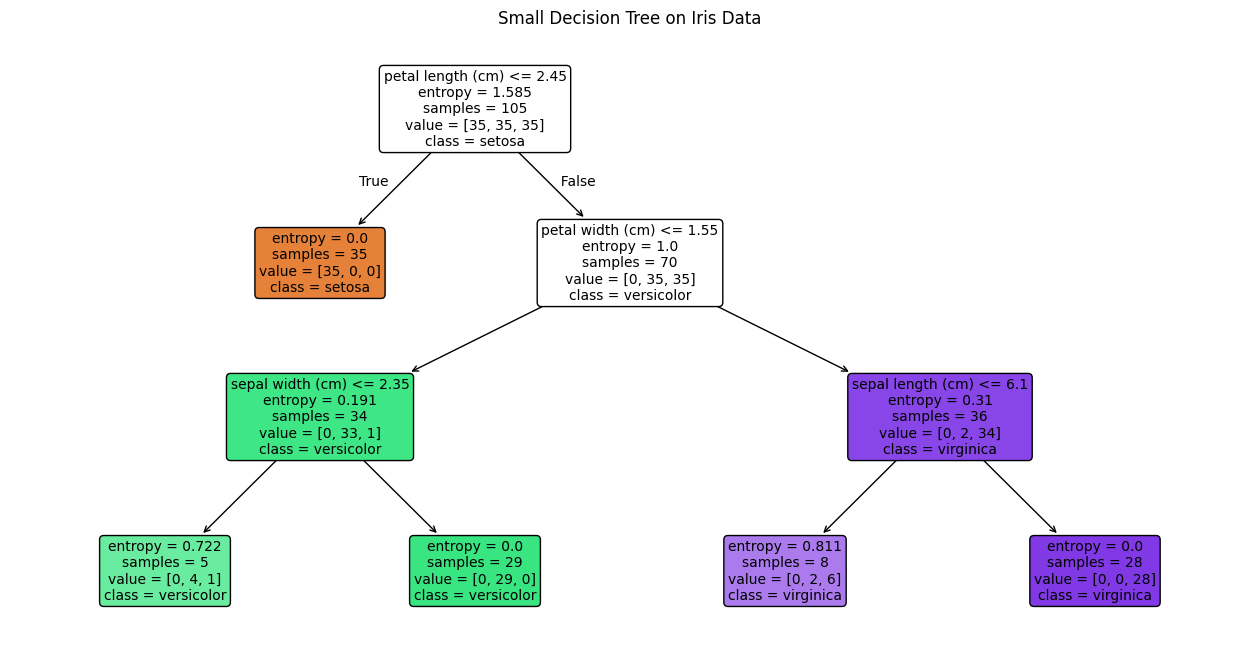

In [12]:
plt.figure(figsize=(16, 8)) # 16 inches wide x 8 inches tall
plot_tree(
    classifier,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Small Decision Tree on Iris Data")
plt.show()

## 7. Show the exact split rules (`export_text`)

This is often easier to read than the graphic when you want the node details clearly.


In [14]:
rules = export_text(classifier, feature_names=feature_names)
print(rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- sepal width (cm) <= 2.35
|   |   |   |--- class: 1
|   |   |--- sepal width (cm) >  2.35
|   |   |   |--- class: 1
|   |--- petal width (cm) >  1.55
|   |   |--- sepal length (cm) <= 6.10
|   |   |   |--- class: 2
|   |   |--- sepal length (cm) >  6.10
|   |   |   |--- class: 2



## 8. Feature importance

In [15]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
2,petal length (cm),0.616814
3,petal width (cm),0.334873
0,sepal length (cm),0.029768
1,sepal width (cm),0.018546
